# HCCB Sales Demand Forecasting
## Hindustan Coca-Cola Beverages Pvt. Ltd.
**Objective:** Forecast brand-wise monthly demand for Sep-Dec 2018
using exponential smoothing models on 4 years of distributor sales data.

**Dataset:** Invoice line-item sales data | Feb 2015 - Aug 2018 | 900K+ rows

## Stage 1 — Library Imports
Importing all required libraries for data manipulation,
visualisation, time series modelling and error evaluation.

In [14]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [15]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("All libraries imported successfully")

All libraries imported successfully


## Stage 2 — Data Loading and Initial Inspection
Loading the raw CSV file and doing a first look at shape,
columns, and data types before any cleaning.

In [98]:
df=pd.read_csv("Salesdf.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_35564\3339887064.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Salesdf.csv")


In [19]:
print("Shape:",df.shape)

Shape: (900428, 17)


In [20]:
df.head()

,Unnamed: 0,STL Code,Outlet ID,Invoice No,InvDate,Inv Line No,Item ID,Item Category,Pack Size,Pack Type,Brand,Qty (CS),Net Amount,Market Area ID,Sales Man Name,Invoice Date_year,Invoice Date_month
0,0,STL0223,G000077951,R2746011500015,02-04-2015,1,100060,Core Sparkling,200,RGB,Limca,5.0,908.70,7824,NaN,2015,4
1,1,STL0223,G000077951,R2746011500015,02-04-2015,2,100980,Core Sparkling,200,RGB,Fanta Orange,2.0,363.48,7824,NaN,2015,4
2,2,STL0223,G000077951,R2746011500015,02-04-2015,3,101237,Core Sparkling,200,RGB,Sprite,15.0,2726.10,7824,NaN,2015,4
3,3,STL0223,G000077951,R2746011500015,02-04-2015,4,100286,Juices/ Nectars,200,RGB,Maaza,20.0,3981.00,7824,NaN,2015,4
4,4,STL0223,G000077951,R2746011500015,02-04-2015,5,101567,Core Sparkling,200,RGB,Thums Up,15.0,2726.10,7824,NaN,2015,4


In [21]:
print(df.columns.tolist())

['Unnamed: 0', 'STL Code', 'Outlet ID', 'Invoice No', 'InvDate', 'Inv Line No', 'Item ID', 'Item Category', 'Pack Size', 'Pack Type', 'Brand', 'Qty (CS)', 'Net Amount', 'Market Area ID', 'Sales Man Name', 'Invoice Date_year', 'Invoice Date_month']


## Stage 3 — Data Cleaning

### Steps performed:
1. **Date parsing** — converted InvDate from string to datetime using dayfirst=True (DD-MM-YYYY format)
2. **Year-Month extraction** — created year_month column for Brand × Month aggregation
3. **Brand standardisation** — stripped whitespace from brand names
4. **Junk removal** — removed 'Not Define in SAP' and 'Multi Brand'
5. **Quantity filtering** — removed zero and negative quantities (product returns)
6. **Sparse brand removal** — removed brands with less than 24 months of data
   (need minimum 2 seasonal cycles for Holt-Winters)

In [23]:
print(df['InvDate'].dtype)

object


In [24]:
print(df['InvDate'].head(10))

0    02-04-2015
1    02-04-2015
2    02-04-2015
3    02-04-2015
4    02-04-2015
5    02-04-2015
6    03-04-2015
7    03-04-2015
8    03-04-2015
9    03-04-2015
Name: InvDate, dtype: object


In [25]:
df['InvDate'] = pd.to_datetime(df['InvDate'], dayfirst = True)

In [26]:
print(df['InvDate'].dtype)

datetime64[ns]


In [27]:
print(df['InvDate'].head(5))

0   2015-04-02
1   2015-04-02
2   2015-04-02
3   2015-04-02
4   2015-04-02
Name: InvDate, dtype: datetime64[ns]


In [28]:
df['year_month'] = df['InvDate'].dt.to_period('M')

In [29]:
print(df['year_month'].dtype)

period[M]


In [30]:
df.head(5)

,Unnamed: 0,STL Code,Outlet ID,Invoice No,InvDate,Inv Line No,Item ID,Item Category,Pack Size,Pack Type,Brand,Qty (CS),Net Amount,Market Area ID,Sales Man Name,Invoice Date_year,Invoice Date_month,year_month
0,0,STL0223,G000077951,R2746011500015,2015-04-02,1,100060,Core Sparkling,200,RGB,Limca,5.0,908.70,7824,NaN,2015,4,2015-04
1,1,STL0223,G000077951,R2746011500015,2015-04-02,2,100980,Core Sparkling,200,RGB,Fanta Orange,2.0,363.48,7824,NaN,2015,4,2015-04
2,2,STL0223,G000077951,R2746011500015,2015-04-02,3,101237,Core Sparkling,200,RGB,Sprite,15.0,2726.10,7824,NaN,2015,4,2015-04
3,3,STL0223,G000077951,R2746011500015,2015-04-02,4,100286,Juices/ Nectars,200,RGB,Maaza,20.0,3981.00,7824,NaN,2015,4,2015-04
4,4,STL0223,G000077951,R2746011500015,2015-04-02,5,101567,Core Sparkling,200,RGB,Thums Up,15.0,2726.10,7824,NaN,2015,4,2015-04


In [31]:
print(df['Brand'].unique())

['Limca                                   ' 'Fanta Orange'
 'Sprite                                  '
 'Maaza                                   '
 'Thums Up                                '
 'Coca-Cola                               ' 'Kinley Water' 'Kinley Soda'
 'Minute Maid                             ' 'Not Define in SAP'
 'Rimzim                                  '
 'Fanta Other                             ' 'Minute Maid Pulpy'
 'Diet Coke' 'Coke Zero' 'Monster-KO' 'Multi Brand']


In [32]:
df['Brand'] = df['Brand'].str.strip()

In [33]:
print(df['Brand'].unique())

['Limca' 'Fanta Orange' 'Sprite' 'Maaza' 'Thums Up' 'Coca-Cola'
 'Kinley Water' 'Kinley Soda' 'Minute Maid' 'Not Define in SAP' 'Rimzim'
 'Fanta Other' 'Minute Maid Pulpy' 'Diet Coke' 'Coke Zero' 'Monster-KO'
 'Multi Brand']


In [34]:
print("\nTotal unique brands:", df['Brand'].nunique())


Total unique brands: 17


In [35]:
junk = ['Not Define in SAP','Multi Brand']
df['Brand'].isin(junk)

0         False
1         False
2         False
3         False
4         False
          ...  
900423    False
900424    False
900425    False
900426    False
900427    False
Name: Brand, Length: 900428, dtype: bool

In [36]:
df = df[~df['Brand'].isin(junk)]

In [37]:
print("\nTotal unique brands:", df['Brand'].nunique())


Total unique brands: 15


In [38]:
print(df['Qty (CS)'].dtype)

float64


In [39]:
print(df['Qty (CS)'].describe())

count    898905.000000
mean          0.682684
std           6.473840
min        -619.000000
25%           0.040000
50%           0.330000
75%           1.000000
max         800.000000
Name: Qty (CS), dtype: float64


In [40]:
df = df[df['Qty (CS)']>0]

In [41]:
df['Qty (CS)'].describe()

count    728992.000000
mean          1.059070
std           6.956894
min           0.020000
25%           0.170000
50%           0.500000
75%           1.000000
max         800.000000
Name: Qty (CS), dtype: float64

In [42]:
print("\n Total rows remaining:", df.shape[0])


 Total rows remaining: 728992


In [43]:
print("Shape:", df.shape)

Shape: (728992, 18)


In [44]:
print("Date range:",df["InvDate"].min(), "to", df["InvDate"].max())

Date range: 2015-02-25 00:00:00 to 2018-08-17 00:00:00


In [45]:
print('Brand:',df['Brand'].unique())

Brand: ['Limca' 'Fanta Orange' 'Sprite' 'Maaza' 'Thums Up' 'Coca-Cola'
 'Kinley Water' 'Kinley Soda' 'Minute Maid' 'Rimzim' 'Fanta Other'
 'Minute Maid Pulpy' 'Diet Coke' 'Coke Zero' 'Monster-KO']


In [46]:
df[['InvDate','Brand','Qty (CS)']].isnull().sum()

InvDate     0
Brand       0
Qty (CS)    0
dtype: int64

In [47]:
brand_months = df.groupby('Brand')['year_month'].nunique().sort_values()
print(brand_months)

Brand
Monster-KO            1
Diet Coke             8
Fanta Other          11
Minute Maid Pulpy    14
Coke Zero            19
Minute Maid          27
Rimzim               29
Coca-Cola            42
Fanta Orange         43
Kinley Soda          43
Kinley Water         43
Limca                43
Maaza                43
Sprite               43
Thums Up             43
Name: year_month, dtype: int64


In [48]:
sparse_brands = ['Monster-KO','Diet Coke', 'Fanta Other', 'Minute Maid Pulpy','Coke Zero']
df = df[~df['Brand'].isin(sparse_brands)]
print(df['Brand'].nunique())
print(df['Brand'].unique())

10
['Limca' 'Fanta Orange' 'Sprite' 'Maaza' 'Thums Up' 'Coca-Cola'
 'Kinley Water' 'Kinley Soda' 'Minute Maid' 'Rimzim']


In [49]:
print("Shape:",df.shape)
print("\nData range:", df['InvDate'].min(), "to", df["InvDate"].max())
print("\nBrands:", df['Brand'].nunique())
print("\nBrand list:", df['Brand'].unique())

Shape: (718535, 18)

Data range: 2015-02-25 00:00:00 to 2018-08-17 00:00:00

Brands: 10

Brand list: ['Limca' 'Fanta Orange' 'Sprite' 'Maaza' 'Thums Up' 'Coca-Cola'
 'Kinley Water' 'Kinley Soda' 'Minute Maid' 'Rimzim']


## Stage 4 — Aggregation and Time Series Creation

Aggregated 718K cleaned rows to Brand × Month level using pandas groupby.
Built individual time series for 10 brands each with 42 complete months
(Mar 2015 - Aug 2018). Stored in a dictionary for clean looping.

**Why dictionary?** Enables looping through all brands with one loop
instead of writing repeated code for each brand separately.

**Why reindex?** Fills missing months with zero so time series is
continuous — gaps break exponential smoothing models.

In [51]:
df_agg = df.groupby(['Brand','year_month'])['Qty (CS)'].sum().reset_index()
df_agg.columns = ['Brand','year_month','total_cases']
print("Shape:",df_agg.shape)
df_agg.head(120)

Shape: (399, 3)


,Brand,year_month,total_cases
0,Coca-Cola,2015-03,838.28
1,Coca-Cola,2015-04,484.56
2,Coca-Cola,2015-05,588.03
3,Coca-Cola,2015-06,443.50
4,Coca-Cola,2015-07,498.62
...,...,...,...
115,Kinley Soda,2017-08,1529.83
116,Kinley Soda,2017-09,1639.07
117,Kinley Soda,2017-10,1341.00
118,Kinley Soda,2017-11,1325.47


In [52]:
all_months = pd.period_range(
    start = df_agg['year_month'].min(),
    end = df_agg['year_month'].max(),
    freq ='M'
)

print("Total months in range:", len(all_months))
print("First_month:", all_months[0])
print("Last_month:", all_months[-1])

Total months in range: 43
First_month: 2015-02
Last_month: 2018-08


In [53]:
brand_ts = {}

for brand in df_agg['Brand'].unique():
    brand_data = df_agg[df_agg['Brand'] == brand][['year_month','total_cases']]
    brand_data = brand_data.set_index('year_month')
    brand_data = brand_data.reindex(all_months, fill_value=0)
    brand_ts[brand] = brand_data

In [54]:
print("Brand in dictionary:", list(brand_ts.keys()))
print("\nShape of Thums Up series:", brand_ts['Thums Up'].shape)
print("\nThums Up first 5 months:")
print(brand_ts['Thums Up'].head())

Brand in dictionary: ['Coca-Cola', 'Fanta Orange', 'Kinley Soda', 'Kinley Water', 'Limca', 'Maaza', 'Minute Maid', 'Rimzim', 'Sprite', 'Thums Up']

Shape of Thums Up series: (43, 1)

Thums Up first 5 months:
         total_cases
2015-02        58.00
2015-03      2968.88
2015-04      4788.90
2015-05      4796.75
2015-06      3613.14


In [55]:
full_months = pd.period_range(start = '2015-03', end = '2018-08', freq='M')
for brand in brand_ts:
    brand_ts[brand] = brand_ts[brand].reindex(full_months, fill_value = 0)
print("New shape of Thums Up:", brand_ts["Thums Up"].shape)
print(brand_ts['Thums Up'].head())

New shape of Thums Up: (42, 1)
         total_cases
2015-03      2968.88
2015-04      4788.90
2015-05      4796.75
2015-06      3613.14
2015-07      3190.73


In [56]:
full_months = pd.period_range(start ='2015-03',end='2018-08',freq='M')
for brand in brand_ts:
    brand_ts[brand] = brand_ts[brand].reindex(full_months, fill_value=0)
print("New shape of Thums Up;", brand_ts['Thums Up'].shape)
print("\nThums Up first 5 months:")
print(brand_ts['Thums Up'].head())

New shape of Thums Up; (42, 1)

Thums Up first 5 months:
         total_cases
2015-03      2968.88
2015-04      4788.90
2015-05      4796.75
2015-06      3613.14
2015-07      3190.73


## Stage 5 — Exploratory Data Analysis (EDA)

Before building any model — understanding patterns in the data visually.

### Charts produced:
1. All brands time series — overall trends and portfolio view
2. Individual brand charts — brand-specific patterns
3. Seasonality heatmap — Brand × Month colour grid
4. Time series decomposition — separates trend, seasonality, residual

### Key Findings:
- All 10 brands show upward trend from 2015-2018
- Portfolio-wide summer peak in April-May (weather-driven)
- Coca-Cola shows winter peak (event-driven — wedding/festival season)
- Thums Up has strongest and most consistent seasonal pattern
- Small residual in decomposition confirms high forecast accuracy potential

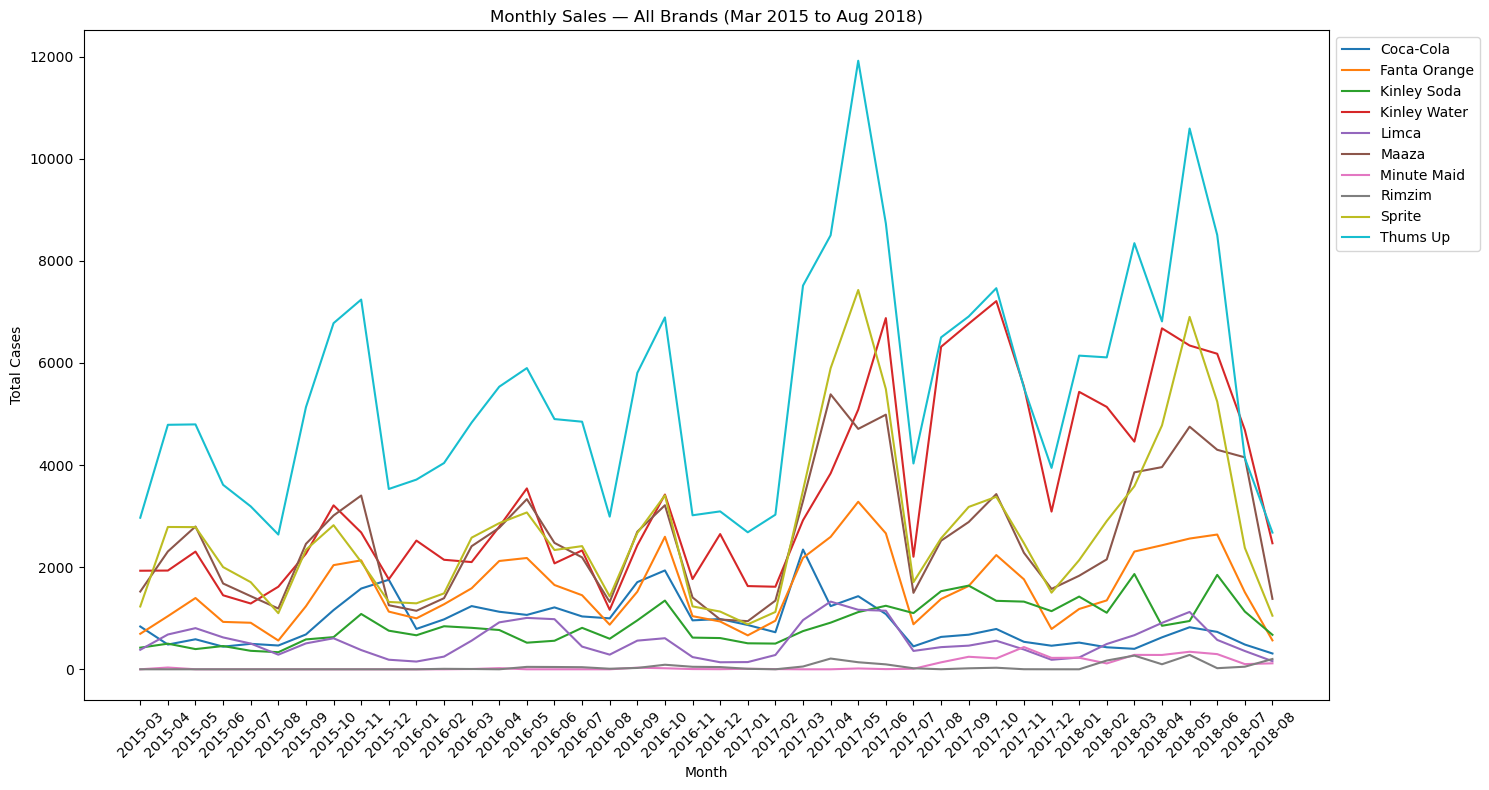

In [58]:
# Plot all brands over time
plt.figure(figsize=(15, 8))

for brand in brand_ts:
    plt.plot(
        brand_ts[brand].index.astype(str), 
        brand_ts[brand]['total_cases'], 
        label=brand
    )

plt.title('Monthly Sales — All Brands (Mar 2015 to Aug 2018)')
plt.xlabel('Month')
plt.ylabel('Total Cases')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

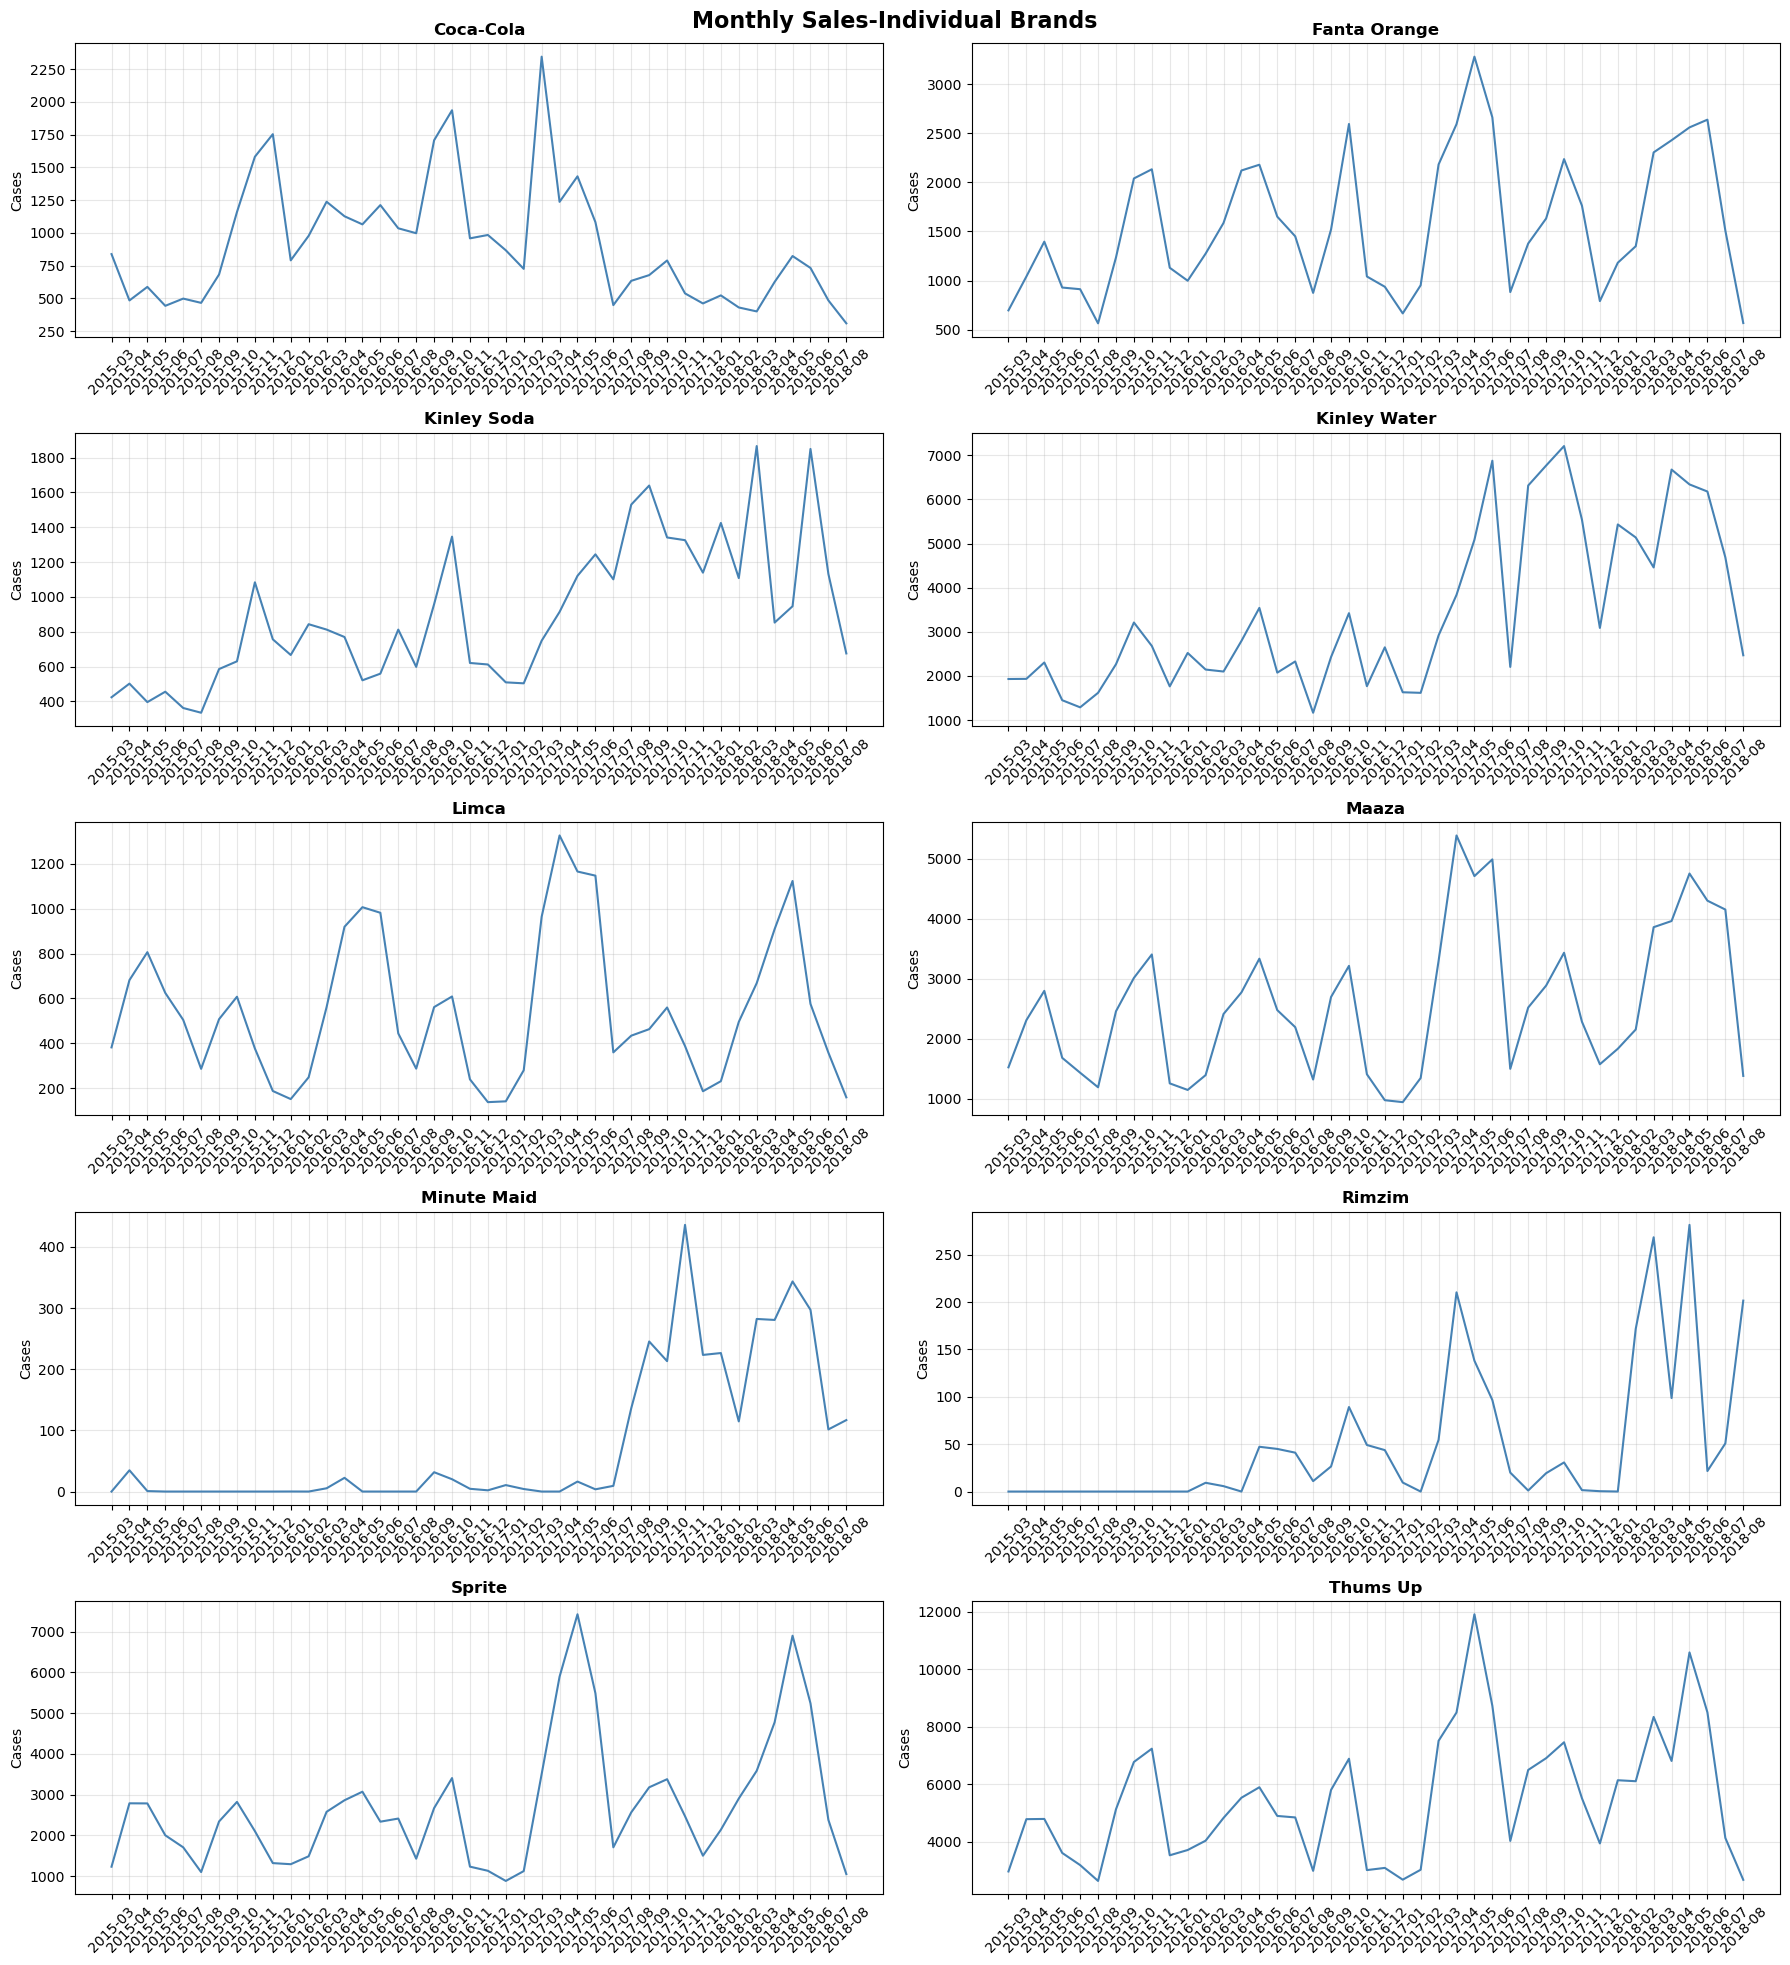

In [59]:
fig, axes = plt.subplots(5,2, figsize=(18,20))
axes = axes.flatten()

for i,brand in enumerate(brand_ts):
    axes[i].plot(
        brand_ts[brand].index.astype(str),
        brand_ts[brand]['total_cases'],
        color='steelblue',
        linewidth=1.5
    )
    axes[i].set_title(brand, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cases')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Monthly Sales-Individual Brands', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

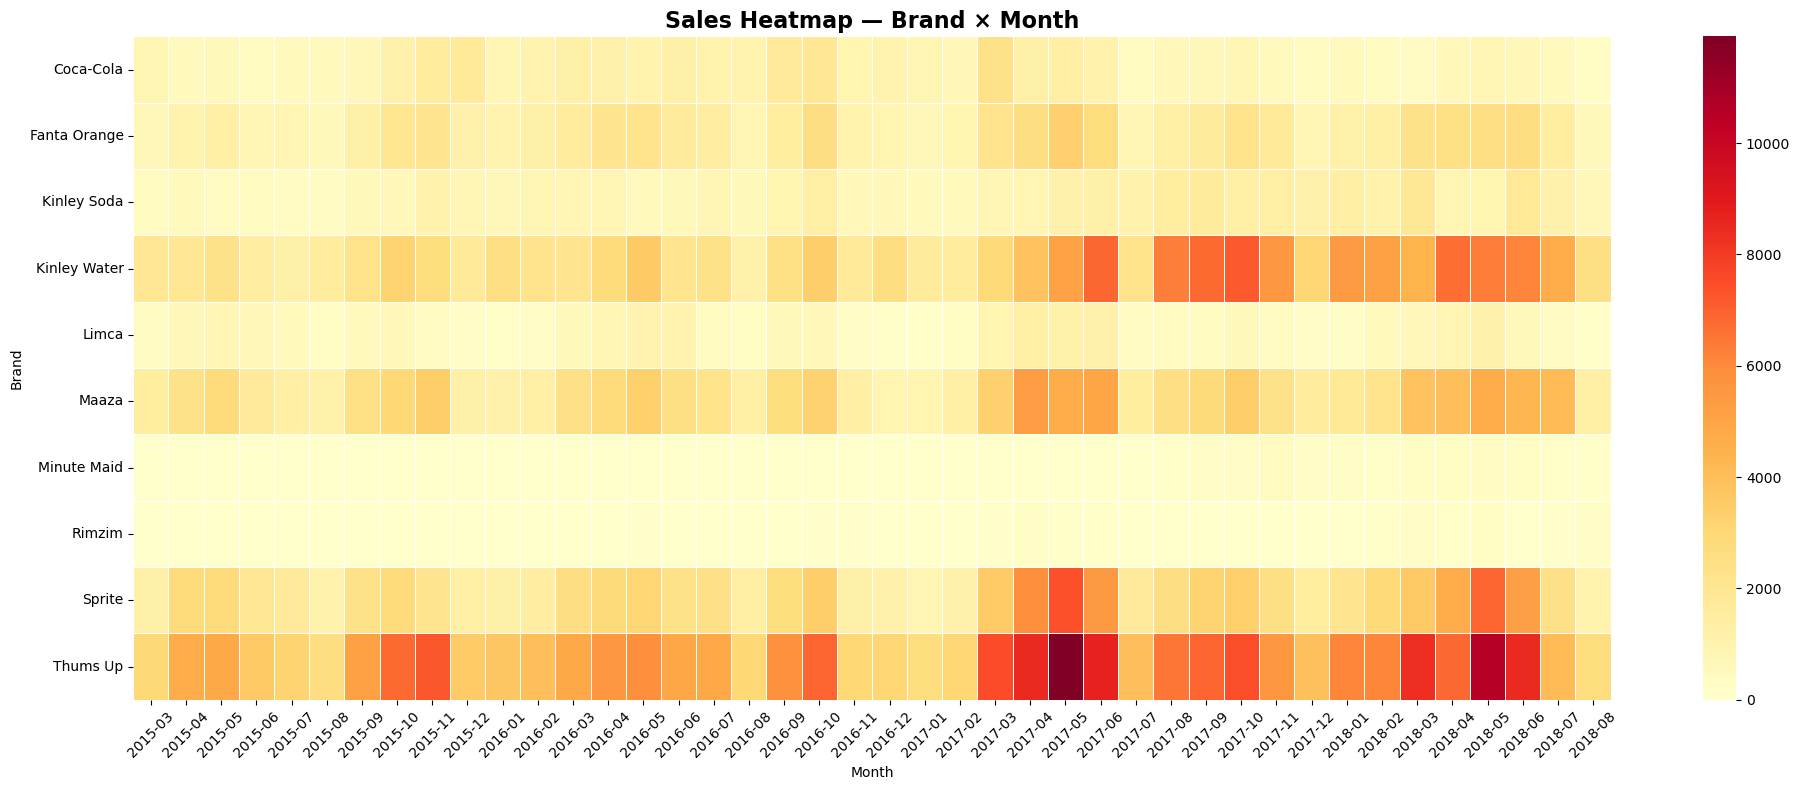

In [60]:
# Prepare data for heatmap
# Create a pivot table — Brands as rows, Months as columns

heatmap_data = pd.DataFrame({
    brand: brand_ts[brand]['total_cases'].values 
    for brand in brand_ts
}).T

# Set month labels as columns
heatmap_data.columns = [str(m) for m in full_months]

# Plot heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=False
)

plt.title('Sales Heatmap — Brand × Month', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

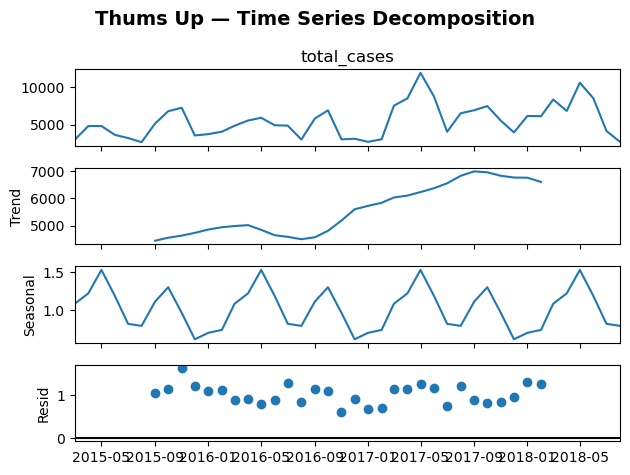

In [61]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Convert index to timestamp first
thums_up_ts = brand_ts['Thums Up']['total_cases'].copy()
thums_up_ts.index = thums_up_ts.index.to_timestamp()

# Decompose Thums Up
result = seasonal_decompose(
    thums_up_ts,
    model='multiplicative',
    period=12
)

# Plot decomposition
result.plot()
plt.suptitle('Thums Up — Time Series Decomposition', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 6 — Train Test Split

Splitting data **chronologically** — never randomly for time series.

- **Train:** Mar 2015 - Dec 2017 (34 months) — model learns from this
- **Test:** Jan 2018 - Aug 2018 (8 months) — hidden from model during training

**Why 8 months test?** Final deliverable is Sep-Dec 2018 forecast —
proving model accuracy over 8 months validates it can forecast reliably.

Zeros replaced with 0.1 before splitting — Holt-Winters Multiplicative
cannot handle zero values mathematically (division by zero).

In [63]:
# Replace zeros with small positive value
for brand in brand_ts:
    brand_ts[brand]['total_cases'] = brand_ts[brand]['total_cases'].replace(0, 0.1)

print("Zeros replaced successfully")

Zeros replaced successfully


In [65]:
# Define train and test split
train_end = pd.Period('2017-12', freq='M')
test_start = pd.Period('2018-01', freq='M')

# Redo train test split after replacing zeros
brand_train = {}
brand_test = {}

for brand in brand_ts:
    brand_train[brand] = brand_ts[brand][brand_ts[brand].index <= train_end]
    brand_test[brand] = brand_ts[brand][brand_ts[brand].index >= test_start]

print("Train test split redone successfully")
print("Thums Up train shape:", brand_train['Thums Up'].shape)
print("Thums Up test shape:", brand_test['Thums Up'].shape)

Train test split redone successfully
Thums Up train shape: (34, 1)
Thums Up test shape: (8, 1)


## Stage 7 — Exponential Smoothing Models

Applied 4 models to all 10 brands:

| Model | Captures | Use When |
|---|---|---|
| SES | Level only | No trend, no seasonality |
| Holt's Linear | Level + Trend | Trend but no seasonality |
| HW Additive | Level + Trend + Constant Seasonality | Seasonal peaks stay same size |
| HW Multiplicative | Level + Trend + Growing Seasonality | Seasonal peaks grow with trend |

Used **optimized=True** — statsmodels automatically finds best
alpha, beta, gamma parameters using Maximum Likelihood Estimation.

In [104]:
import warnings
warnings.filterwarnings('ignore')

In [106]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Store results
results = {}

for brand in brand_ts:
    
    # Get train and test data
    train = brand_train[brand]['total_cases'].copy()
    test = brand_test[brand]['total_cases'].copy()
    
    # Convert index to timestamp
    train.index = train.index.to_timestamp()
    test.index = test.index.to_timestamp()
    
    brand_results = {}
    
    # Model 1 — Simple Exponential Smoothing
    model_ses = SimpleExpSmoothing(train).fit(optimized=True)
    pred_ses = model_ses.forecast(len(test))
    
    # Model 2 — Holt's Linear
    model_holt = Holt(train).fit(optimized=True)
    pred_holt = model_holt.forecast(len(test))
    
    # Model 3 — Holt-Winters Additive
    model_hwa = ExponentialSmoothing(
        train, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12
    ).fit(optimized=True)
    pred_hwa = model_hwa.forecast(len(test))
    
    # Model 4 — Holt-Winters Multiplicative
    model_hwm = ExponentialSmoothing(
        train,
        trend='add',
        seasonal='mul',
        seasonal_periods=12
    ).fit(optimized=True)
    pred_hwm = model_hwm.forecast(len(test))
    
    # Store predictions
    brand_results['SES'] = pred_ses
    brand_results['Holt'] = pred_holt
    brand_results['HW_Additive'] = pred_hwa
    brand_results['HW_Multiplicative'] = pred_hwm
    brand_results['actual'] = test
    
    results[brand] = brand_results

print("Models trained for all brands successfully")

Models trained for all brands successfully


## Stage 8 — Model Evaluation (MAE and MSE)

**MAE (Mean Absolute Error):** Average absolute difference between
actual and predicted values. Interpretable in original units (cases).

**MSE (Mean Squared Error):** Average of squared errors. Penalises
large errors more heavily — important for catching missed summer peaks.

Selected best model per brand based on lowest MAE.

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate errors for all brands and all models
error_results = {}

for brand in results:
    actual = results[brand]['actual'].values
    
    brand_errors = {}
    
    for model_name in ['SES', 'Holt', 'HW_Additive', 'HW_Multiplicative']:
        predicted = results[brand][model_name].values
        
        mae = mean_absolute_error(actual, predicted)
        mse = mean_squared_error(actual, predicted)
        
        brand_errors[model_name] = {
            'MAE': round(mae, 2),
            'MSE': round(mse, 2)
        }
    
    error_results[brand] = brand_errors

# Print results for Thums Up
print("Thums Up Error Results:")
for model, errors in error_results['Thums Up'].items():
    print(f"{model:20} MAE: {errors['MAE']:10.2f}  MSE: {errors['MSE']:15.2f}")

Thums Up Error Results:
SES                  MAE:    3037.71  MSE:     12970313.70
Holt                 MAE:    3778.32  MSE:     19252991.61
HW_Additive          MAE:    2300.77  MSE:      6396433.17
HW_Multiplicative    MAE:    2223.30  MSE:      6460077.29


In [111]:
# Print error results for all brands
for brand in error_results:
    print(f"\n{brand}:")
    print(f"{'Model':20} {'MAE':>10} {'MSE':>15}")
    print("-" * 50)
    for model, errors in error_results[brand].items():
        print(f"{model:20} {errors['MAE']:>10.2f} {errors['MSE']:>15.2f}")


Coca-Cola:
Model                       MAE             MSE
--------------------------------------------------
SES                      154.81        30337.88
Holt                     377.59       194366.56
HW_Additive              720.74       587987.89
HW_Multiplicative        775.94       670837.10

Fanta Orange:
Model                       MAE             MSE
--------------------------------------------------
SES                     1080.06      1561982.10
Holt                    1155.86      1847472.05
HW_Additive              582.86       395256.65
HW_Multiplicative        532.65       328345.82

Kinley Soda:
Model                       MAE             MSE
--------------------------------------------------
SES                      351.53       174103.55
Holt                     452.82       254192.73
HW_Additive              421.88       218596.89
HW_Multiplicative        426.52       242342.09

Kinley Water:
Model                       MAE             MSE
-----------------------

In [113]:
# Find best model per brand based on MAE
best_models = {}

for brand in error_results:
    brand_errors = error_results[brand]
    
    # Find model with lowest MAE
    best_model = min(brand_errors, key=lambda x: brand_errors[x]['MAE'])
    best_mae = brand_errors[best_model]['MAE']
    best_mse = brand_errors[best_model]['MSE']
    
    best_models[brand] = {
        'Best Model': best_model,
        'MAE': best_mae,
        'MSE': best_mse
    }

# Convert to dataframe for clean display
best_models_df = pd.DataFrame(best_models).T
best_models_df = best_models_df.sort_values('MAE')
print(best_models_df)

                     Best Model     MAE         MSE
Minute Maid                 SES   80.52    10233.39
Rimzim        HW_Multiplicative  115.31    17667.36
Coca-Cola                   SES  154.81    30337.88
Limca         HW_Multiplicative  156.06    35023.22
Kinley Soda                 SES  351.53   174103.55
Fanta Orange  HW_Multiplicative  532.65   328345.82
Maaza               HW_Additive  729.81   942805.43
Kinley Water        HW_Additive  772.68  1288314.55
Sprite        HW_Multiplicative  855.89   924059.95
Thums Up      HW_Multiplicative  2223.3  6460077.29


## Stage 9 — Final Forecasts (Sep-Dec 2018)

Retrained best model per brand on **full 42 months** of data
(not just train set) before generating final forecasts.

**Why full data for final forecast?**
More recent data improves model accuracy — we no longer need
to hold out test data once model selection is complete.

In [116]:
# Final forecast — Sep to Dec 2018
forecast_months = pd.period_range(start='2018-09', end='2018-12', freq='M')
final_forecasts = {}

for brand in brand_ts:
    # Get best model for this brand
    best_model_name = best_models[brand]['Best Model']
    
    # Get FULL data for this brand
    full_data = brand_ts[brand]['total_cases'].copy()
    full_data.index = full_data.index.to_timestamp()
    
    # Retrain best model on full data
    if best_model_name == 'SES':
        model = SimpleExpSmoothing(full_data).fit(optimized=True)
        
    elif best_model_name == 'Holt':
        model = Holt(full_data).fit(optimized=True)
        
    elif best_model_name == 'HW_Additive':
        model = ExponentialSmoothing(
            full_data,
            trend='add',
            seasonal='add',
            seasonal_periods=12
        ).fit(optimized=True)
        
    elif best_model_name == 'HW_Multiplicative':
        model = ExponentialSmoothing(
            full_data,
            trend='add',
            seasonal='mul',
            seasonal_periods=12
        ).fit(optimized=True)
    
    # Forecast 4 months ahead
    forecast = model.forecast(4)
    forecast.index = forecast_months
    
    final_forecasts[brand] = forecast

print("Final forecasts generated successfully")

Final forecasts generated successfully


In [117]:
# Display final forecasts for all brands
forecast_df = pd.DataFrame(final_forecasts)
forecast_df.index = ['Sep-2018', 'Oct-2018', 'Nov-2018', 'Dec-2018']
print(forecast_df.round(2))

          Coca-Cola  Fanta Orange  Kinley Soda  Kinley Water   Limca    Maaza  \
Sep-2018     488.03       1214.21      1083.13       4918.02  315.00  3764.83   
Oct-2018     488.03       1889.88      1083.13       5861.08  376.12  4269.74   
Nov-2018     488.03       1331.51      1083.13       4717.53  223.80  3464.95   
Dec-2018     488.03        763.89      1083.13       4480.42  125.91  2215.23   

          Minute Maid  Rimzim   Sprite  Thums Up  
Sep-2018       127.14   18.83  2104.77   4840.91  
Oct-2018       127.14   79.96  2522.24   5889.71  
Nov-2018       127.14   30.41  1647.62   4365.26  
Dec-2018       127.14   28.94  1234.10   2668.87  


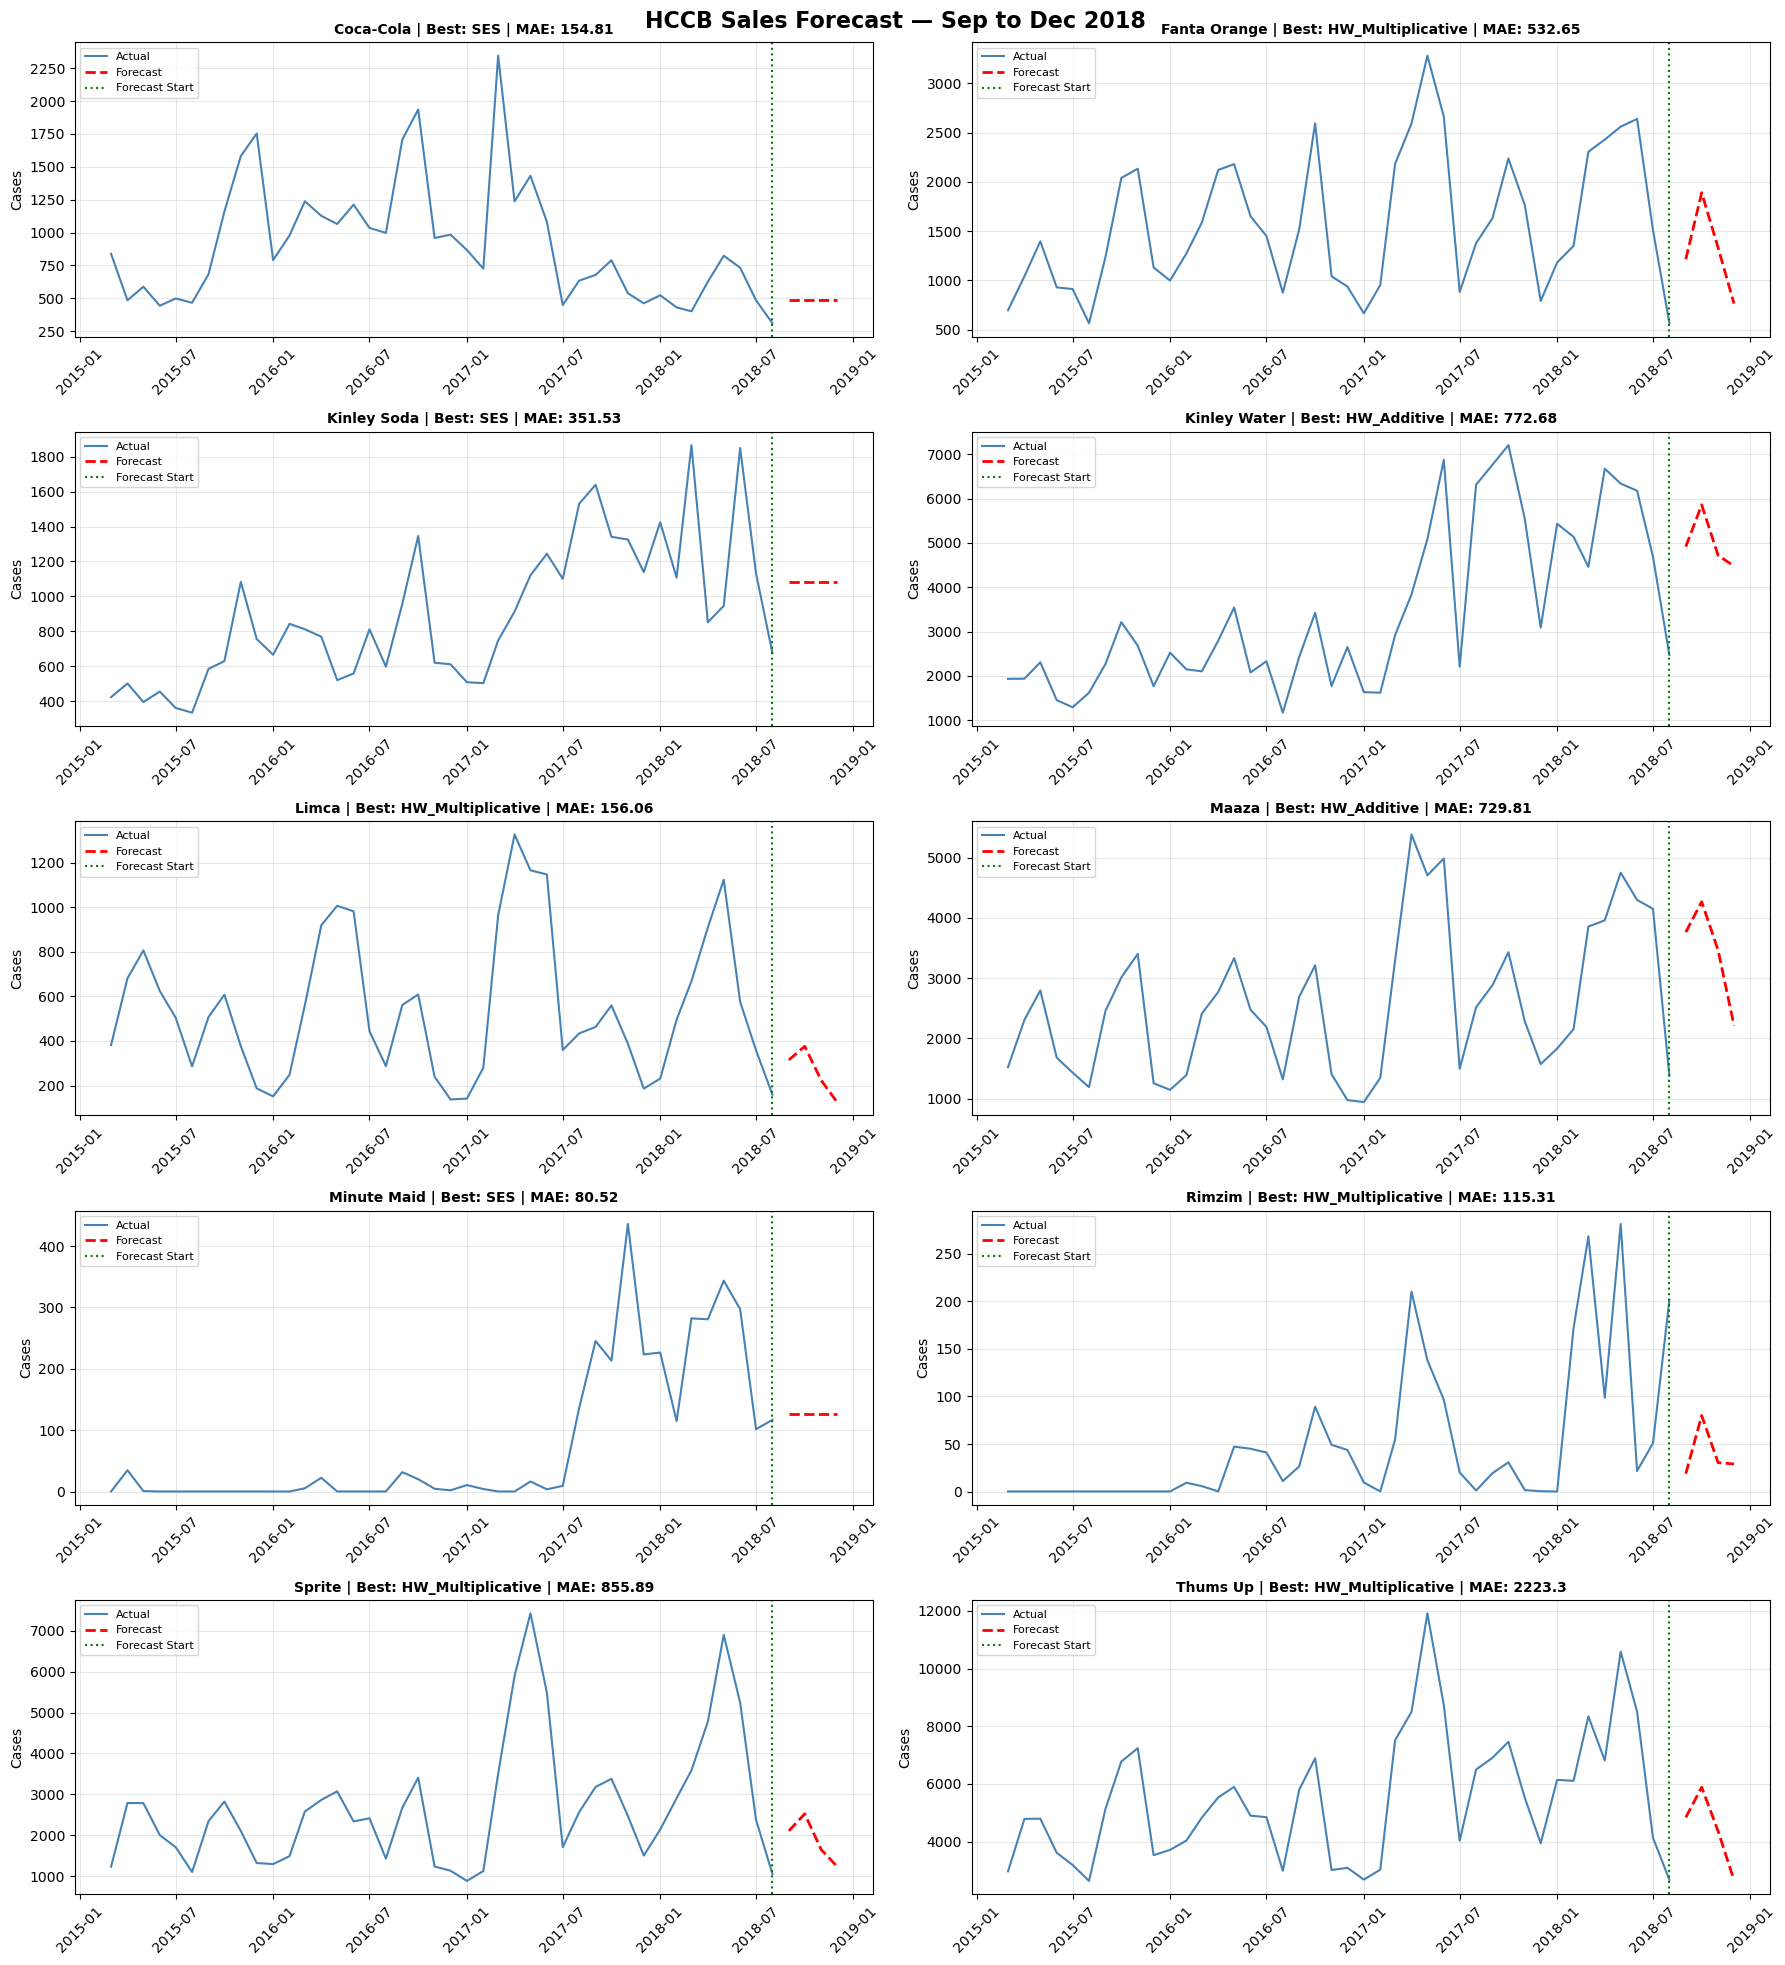

In [120]:
# Plot actual vs forecast for each brand
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, brand in enumerate(brand_ts):
    # Get actual data
    actual = brand_ts[brand]['total_cases'].copy()
    actual.index = actual.index.to_timestamp()
    
    # Get forecast
    forecast = final_forecasts[brand]
    forecast.index = forecast.index.to_timestamp()
    
    # Plot actual
    axes[i].plot(
        actual.index,
        actual.values,
        color='steelblue',
        label='Actual',
        linewidth=1.5
    )
    
    # Plot forecast
    axes[i].plot(
        forecast.index,
        forecast.values,
        color='red',
        label='Forecast',
        linewidth=2,
        linestyle='--'
    )
    
    # Add vertical line separating actual and forecast
    axes[i].axvline(
        x=pd.Timestamp('2018-08-01'),
        color='green',
        linestyle=':',
        linewidth=1.5,
        label='Forecast Start'
    )
    
    axes[i].set_title(
        f"{brand} | Best: {best_models[brand]['Best Model']} | MAE: {best_models[brand]['MAE']}",
        fontsize=10,
        fontweight='bold'
    )
    axes[i].set_ylabel('Cases')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle(
    'HCCB Sales Forecast — Sep to Dec 2018',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

## Conclusions

1. **HW_Multiplicative** was best for 5 brands — high volume carbonated
   drinks with strong growing seasonality (Thums Up, Sprite, Fanta Orange, Limca, Rimzim)
2. **SES** outperformed complex models for irregular brands
   (Coca-Cola, Kinley Soda, Minute Maid) — simpler is better when no clear pattern exists
3. **Holt's Linear** never won — confirms seasonality cannot be ignored in this dataset
4. **Thums Up** had the highest sales and strongest seasonal pattern —
   most critical brand for inventory planning
5. **Portfolio-wide upward trend** confirms HCCB distributor network expansion 2015-2018

In [102]:
# Save directly to desktop as CSV
import os

desktop = os.path.join(os.path.expanduser("~"), "Desktop")
file_path = os.path.join(desktop, "Salesdf_sample.csv")

df_sample = pd.read_csv("D:/Toby_Mammen/Salesdf.csv", low_memory=False, nrows=10000)
df_sample.to_csv(file_path, index=False)

print("File saved to:", file_path)

File saved to: C:\Users\HP\Desktop\Salesdf_sample.csv
